In [1]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('train.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,169,170,171,172,173,174,175,176,177,y
0,0.903271,0.839936,0.713194,0.543006,0.374627,0.236815,0.176350,0.190807,0.206056,0.195678,...,0.826477,0.830169,0.860925,0.892772,0.826691,0.713564,0.636703,0.650729,0.716417,1
1,0.160704,0.196900,0.317191,0.429903,0.617860,0.872943,1.077452,1.181534,1.202762,1.078247,...,3.397871,2.394167,0.368320,-1.974210,-2.757167,-2.307936,-0.528052,1.200682,2.326928,1
2,0.088843,0.125451,0.085384,0.002077,-0.141623,-0.240281,-0.180130,-0.103468,-0.000159,0.080994,...,0.021392,0.084487,0.157887,0.214253,0.223754,0.196858,0.238496,0.320758,0.327333,0
3,0.476894,0.496983,0.457241,0.459408,0.419302,0.395847,0.339737,0.288899,0.240425,0.190692,...,0.309271,0.307223,0.344407,0.381494,0.402223,0.428146,0.382846,0.360754,0.351959,0
4,0.520010,0.301691,0.206117,0.149603,-0.032417,-0.150825,-0.165277,-0.152514,-0.157276,-0.263058,...,0.216565,-0.114039,-0.521239,-0.703181,-0.808474,-0.826712,-0.597738,-0.174200,0.406135,1


In [3]:
df.shape

(10869, 179)

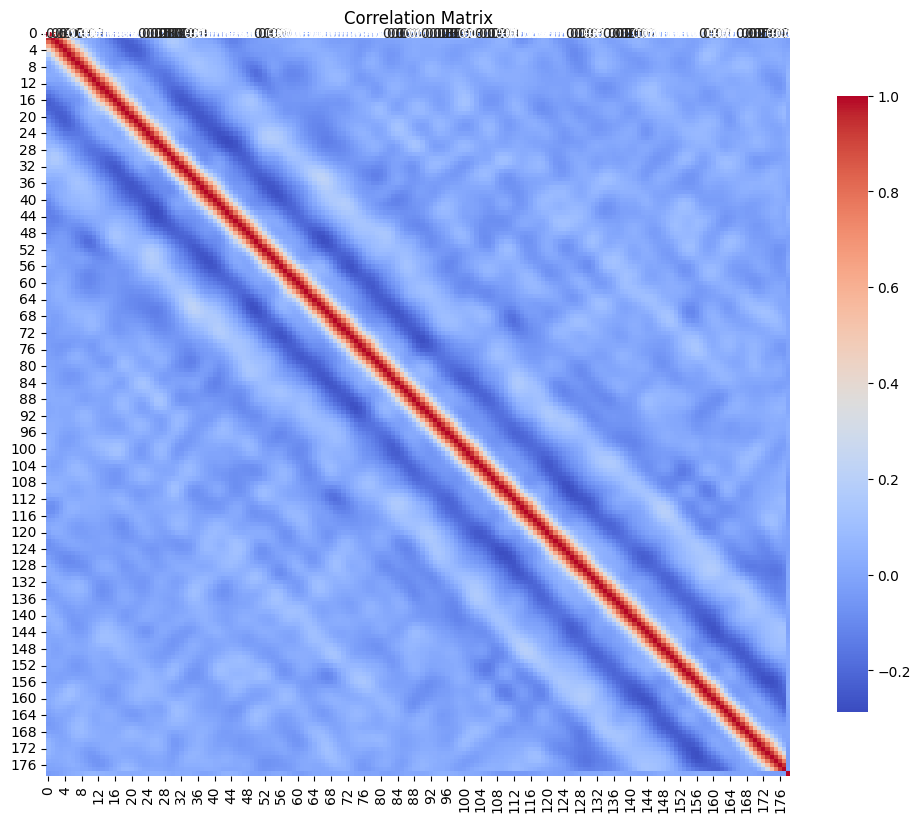

In [4]:
#correlation matrix
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

In [6]:
X = df.drop(columns=['y'])
y = df['y']


In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#lstm model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_log_error

# Reshape the data for LSTM input
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


In [11]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

In [12]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')

In [13]:
# Train the model
history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping, model_checkpoint], verbose=1)

Epoch 1/50


218/218 [==============================] - 6s 7ms/step - loss: 0.4075 - accuracy: 0.8125 - val_loss: 0.3649 - val_accuracy: 0.9109
Epoch 2/50
 46/218 [=====>........................] - ETA: 0s - loss: 0.2230 - accuracy: 0.9137

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


218/218 [==============================] - 1s 4ms/step - loss: 0.2013 - accuracy: 0.9265 - val_loss: 0.1277 - val_accuracy: 0.9592
Epoch 3/50
218/218 [==============================] - 1s 4ms/step - loss: 0.1518 - accuracy: 0.9439 - val_loss: 0.0938 - val_accuracy: 0.9695
Epoch 4/50
218/218 [==============================] - 1s 4ms/step - loss: 0.1426 - accuracy: 0.9455 - val_loss: 0.0906 - val_accuracy: 0.9701
Epoch 5/50
218/218 [==============================] - 1s 4ms/step - loss: 0.1284 - accuracy: 0.9524 - val_loss: 0.0790 - val_accuracy: 0.9741
Epoch 6/50
218/218 [==============================] - 1s 4ms/step - loss: 0.1208 - accuracy: 0.9566 - val_loss: 0.0810 - val_accuracy: 0.9707
Epoch 7/50
218/218 [==============================] - 1s 4ms/step - loss: 0.1065 - accuracy: 0.9595 - val_loss: 0.0761 - val_accuracy: 0.9747
Epoch 8/50
218/218 [==============================] - 1s 3ms/step - loss: 0.1014 - accuracy: 0.9618 - val_loss: 0.0731 - val_accuracy: 0.9758
Epoch 9/50
218/21

In [14]:
# Evaluate the model
model.load_weights('best_model.h5')

68/68 [==============================] - 1s 2ms/step
Accuracy: 0.9853
F1 Score: 0.9855
Precision: 0.9837
Recall: 0.9873
ROC AUC: 0.9967
Mean Squared Error: 0.0106
Mean Absolute Error: 0.0189
R2 Score: 0.9576
Mean Absolute Percentage Error: 45718921970135.0312
Mean Squared Log Error: 0.0051
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1074
           1       0.98      0.99      0.99      1100

    accuracy                           0.99      2174
   macro avg       0.99      0.99      0.99      2174
weighted avg       0.99      0.99      0.99      2174



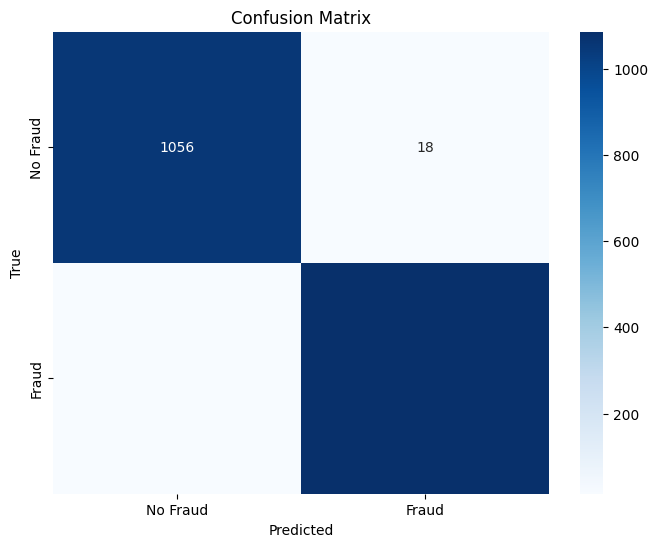

In [15]:
#evaluate the model on test data
y_pred = model.predict(X_test_reshaped)
y_pred_classes = (y_pred > 0.5).astype(int)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
roc_auc = roc_auc_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
msle = mean_squared_log_error(y_test, y_pred)
# Print the metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')
print(f'Mean Absolute Percentage Error: {mape:.4f}')
print(f'Mean Squared Log Error: {msle:.4f}')
# Print classification report
print(classification_report(y_test, y_pred_classes))
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

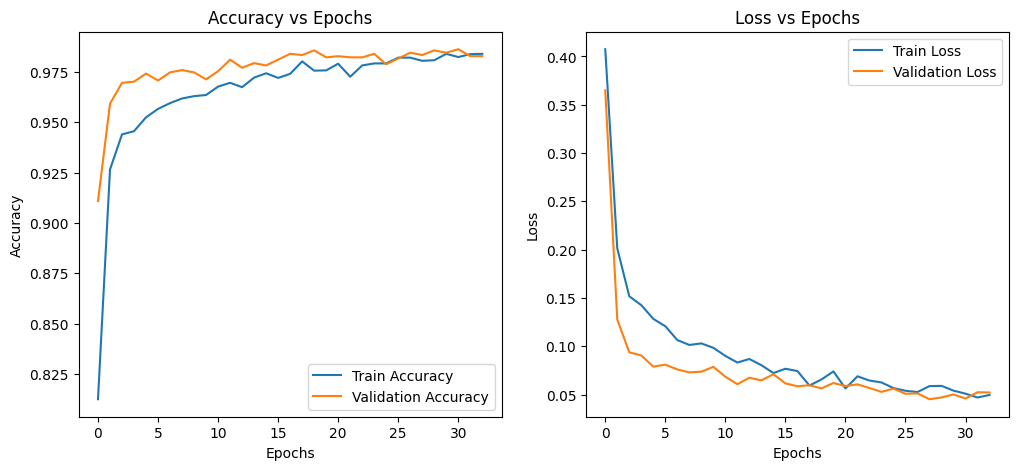

In [16]:
#epochs vs accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

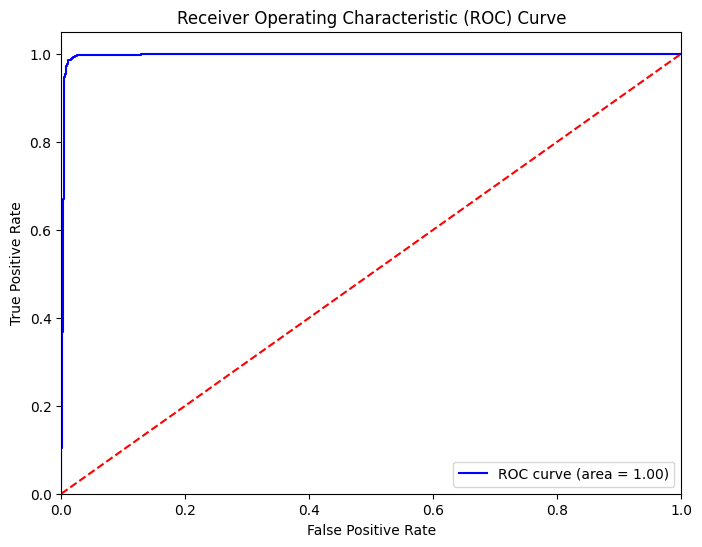

In [17]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [18]:
# Save the model
model.save('lstm_model.h5')

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [19]:
# Load the model
from tensorflow.keras.models import load_model
loaded_model = load_model('lstm_model.h5')

In [20]:
#take rabdom sample from test data and predict
import random
random_index = random.randint(0, len(X_test_reshaped) - 1)
sample = X_test_reshaped[random_index].reshape(1, 1, X_test_reshaped.shape[2])
sample_prediction = loaded_model.predict(sample)
sample_prediction_class = (sample_prediction > 0.5).astype(int)
print(f'Sample Index: {random_index}')
print(f'Sample Prediction: {sample_prediction[0][0]:.4f}')
print(f'Sample Prediction Class: {sample_prediction_class[0][0]}')

1/1 [==============================] - 1s 1s/step
Sample Index: 1023
Sample Prediction: 0.9998
Sample Prediction Class: 1


In [24]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
4568,1.918911,1.182889,0.172311,-0.981432,-1.993174,-2.754973,-3.220112,-3.428781,-3.451808,-3.060353,...,-3.676400,-3.189190,-2.501193,-1.731231,-1.028106,-0.268243,0.260831,0.766121,0.925706,0.913421
1511,0.390660,0.373139,0.529681,0.739708,1.114254,1.519010,1.820119,1.927032,1.796858,1.522025,...,0.635057,0.875271,1.009327,0.980490,0.935777,0.971396,0.871036,0.313160,-0.639160,-1.657486
2638,1.880585,1.425814,0.954660,0.154520,-0.593342,-1.293867,-1.813996,-1.942690,-1.880645,-1.554501,...,-0.713182,-0.290883,0.031223,0.200930,0.266814,0.233401,0.182095,0.109079,-0.009214,-0.155327
5527,3.394463,3.064365,2.630432,2.219888,1.938269,1.782406,1.755754,1.760276,1.791948,1.866077,...,1.231581,1.036288,1.057748,1.181358,1.270258,1.391040,1.579662,1.756660,1.665642,1.302505
1713,0.131959,0.154030,0.162653,0.188943,0.195925,0.221906,0.215959,0.215330,0.210966,0.180719,...,0.188877,0.192168,0.195855,0.200930,0.204696,0.194813,0.206700,0.203653,0.205768,0.184505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4110,-0.006973,0.087345,0.162653,0.139768,0.056934,-0.001733,0.072377,0.185902,0.201146,0.155788,...,-0.048762,0.089703,0.176486,0.172234,0.113909,0.021167,-0.059034,-0.174643,-0.214196,-0.175028
6131,-1.070520,-1.051067,-1.059164,-1.069947,-1.079809,-1.065259,-1.036672,-1.005913,-0.982136,-0.981080,...,0.974542,1.002132,1.019011,1.009185,1.026565,1.048572,1.112166,1.179260,1.215681,1.253254
8233,-0.189021,-0.193686,-0.141594,-0.115944,-0.121768,-0.165735,-0.209837,-0.250606,-0.275113,-0.337852,...,-0.722882,-0.705624,-0.695091,-0.674282,-0.664955,-0.658946,-0.669240,-0.672402,-0.609162,-0.509935
8524,-0.050089,-0.022209,0.027432,-0.056934,-0.121768,-0.195553,-0.214788,-0.191751,-0.226014,-0.273031,...,0.150079,0.065306,0.007013,-0.086025,-0.091558,-0.041538,-0.073797,-0.075092,-0.054210,0.007201


In [30]:
#take a random data point from the and save it to a csv file test data point 1 
random_index = random.randint(0, len(X_test) - 1)
sample = X_test[:1]
sample.to_csv('sample_test_data.csv', index=False)

In [31]:
sample.head()

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
4568,1.918911,1.182889,0.172311,-0.981432,-1.993174,-2.754973,-3.220112,-3.428781,-3.451808,-3.060353,...,-3.6764,-3.18919,-2.501193,-1.731231,-1.028106,-0.268243,0.260831,0.766121,0.925706,0.913421


In [33]:
#take the test data oint 1 and make a prediction on this
data1= pd.read_csv('sample_test_data.csv')
data1_scaled = scaler.transform(data1)
data1_reshaped = data1_scaled.reshape((data1_scaled.shape[0], 1, data1_scaled.shape[1]))
data1_prediction = loaded_model.predict(data1_reshaped)
data1_prediction_class = (data1_prediction > 0.5).astype(int)
print(f'Sample Data 1 Prediction: {data1_prediction[0][0]:.4f}')
print(f'Sample Data 1 Prediction Class: {data1_prediction_class[0][0]}')

1/1 [==============================] - 0s 21ms/step
Sample Data 1 Prediction: 0.9995
Sample Data 1 Prediction Class: 1


In [45]:
sample1 = X_test[4:5]
sample1.to_csv('sample_test_data1.csv', index=False)
sample1.head()
#take the test data oint 2 and make a prediction on this
data2= pd.read_csv('sample_test_data1.csv')
data2_scaled = scaler.transform(data2)
data2_reshaped = data2_scaled.reshape((data2_scaled.shape[0], 1, data2_scaled.shape[1]))
data2_prediction = loaded_model.predict(data2_reshaped)
data2_prediction_class = (data2_prediction > 0.5).astype(int)
print(f'Sample Data 2 Prediction: {data2_prediction[0][0]:.4f}')
print(f'Sample Data 2 Prediction Class: {data2_prediction_class[0][0]}')

1/1 [==============================] - 0s 24ms/step
Sample Data 2 Prediction: 0.0002
Sample Data 2 Prediction Class: 0


In [46]:
sample2= X_test[5:6]
sample2.to_csv('sample_test_data2.csv', index=False)
sample2.head()


,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
5317,-1.19508,-1.322572,-1.43585,-1.448598,-1.382609,-1.229261,-1.066379,-0.961772,-0.967407,-1.050888,...,0.242225,0.343426,0.46217,0.573971,0.692083,0.821868,0.910404,0.805941,0.415749,-0.179953


In [47]:
#take the test data oint 3 and make a prediction on this
data3= pd.read_csv('sample_test_data2.csv')
data3_scaled = scaler.transform(data3)
data3_reshaped = data3_scaled.reshape((data3_scaled.shape[0], 1, data3_scaled.shape[1]))
data3_prediction = loaded_model.predict(data3_reshaped)
data3_prediction_class = (data3_prediction > 0.5).astype(int)
print(f'Sample Data 3 Prediction: {data3_prediction[0][0]:.4f}')
print(f'Sample Data 3 Prediction Class: {data3_prediction_class[0][0]}')

1/1 [==============================] - 0s 32ms/step
Sample Data 3 Prediction: 0.9996
Sample Data 3 Prediction Class: 1


In [48]:
#take the test data oint 4 and make a prediction on this
sample3= X_test[6:7]
sample3.to_csv('sample_test_data3.csv', index=False)
sample3.head()

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
5635,0.462521,0.430298,0.38963,0.218449,0.166141,0.33124,0.874457,1.539569,2.042353,2.205143,...,1.774756,1.22658,0.757538,0.110061,-0.674512,-1.353529,-1.825677,-1.83218,-1.539082,-1.1699


In [49]:
#take the test data oint 4 and make a prediction on this
data4= pd.read_csv('sample_test_data3.csv')
data4_scaled = scaler.transform(data4)
data4_reshaped = data4_scaled.reshape((data4_scaled.shape[0], 1, data4_scaled.shape[1]))
data4_prediction = loaded_model.predict(data4_reshaped)
data4_prediction_class = (data4_prediction > 0.5).astype(int)
print(f'Sample Data 4 Prediction: {data4_prediction[0][0]:.4f}')
print(f'Sample Data 4 Prediction Class: {data4_prediction_class[0][0]}')


1/1 [==============================] - 0s 17ms/step
Sample Data 4 Prediction: 0.9992
Sample Data 4 Prediction Class: 1


In [54]:
#take the test data oint 5 and make a prediction on this
sample4= X_test[9:10]
sample4.to_csv('sample_test_data4.csv', index=False)
sample4.head()
#take the test data oint 5 and make a prediction on this
data5= pd.read_csv('sample_test_data4.csv')
data5_scaled = scaler.transform(data5)
data5_reshaped = data5_scaled.reshape((data5_scaled.shape[0], 1, data5_scaled.shape[1]))
data5_prediction = loaded_model.predict(data5_reshaped)
data5_prediction_class = (data5_prediction > 0.5).astype(int)
print(f'Sample Data 5 Prediction: {data5_prediction[0][0]:.4f}')
print(f'Sample Data 5 Prediction Class: {data5_prediction_class[0][0]}')


1/1 [==============================] - 0s 21ms/step
Sample Data 5 Prediction: 0.0033
Sample Data 5 Prediction Class: 0


In [55]:
#save scaler to disk
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
#load scaler from disk
scaler = joblib.load('scaler.pkl')
